In [1]:
import torch
import torch.nn as nn
import math

In [2]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim: int, mlp_dim: int = 256):
        super().__init__()

        self.dim = dim

        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.SiLU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, t: torch.Tensor):
        """
        t: (B, L)  -> scalar timestep per token
        return: (B, L, dim)
        """

        B, L = t.size()

        t_emb = self._sinusoidal_embedding(t, self.dim)  # (B, L, dim)
        t_emb = self.mlp(t_emb)  # (B, L, dim)

        return t_emb

    def _sinusoidal_embedding(self, t, dim):
        """
        t: (B, )
        """
        device = t.device

        half = dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=device) / (half - 1)
        )

        args = t.to(freqs.dtype) * freqs  # (B, L, dim/2)

        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

        if dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[..., :1])], dim=-1)

        return emb

In [3]:
timestep_embedding = TimestepEmbedding(dim=128)
t_embed = timestep_embedding(torch.tensor([[5], [10]]))
t_embed, t_embed.size()

(tensor([[-0.1610,  0.0716,  0.0354, -0.0083, -0.0867, -0.2040,  0.1424,  0.1222,
           0.0477,  0.1038, -0.0494,  0.1941, -0.0628, -0.0087, -0.0236,  0.0629,
          -0.1121, -0.0066,  0.0412, -0.2139, -0.1582, -0.2159,  0.0661,  0.0734,
          -0.1241, -0.0992, -0.0662,  0.1541, -0.1142, -0.0360, -0.0347,  0.0587,
          -0.0850, -0.0141,  0.0269, -0.0260, -0.1637,  0.1032,  0.1382, -0.0887,
           0.0024,  0.0196,  0.2075,  0.0520, -0.0300,  0.1043, -0.2373,  0.0187,
           0.0999,  0.0146, -0.1268,  0.0517,  0.1701,  0.1284, -0.0169, -0.0827,
           0.0301,  0.0250,  0.1606, -0.2536, -0.1354,  0.1883,  0.1536, -0.1812,
          -0.1556, -0.0095, -0.0008, -0.2153,  0.0290,  0.0848,  0.2555,  0.0893,
          -0.0239,  0.1158,  0.0954,  0.2658,  0.0296, -0.1060,  0.2173,  0.3166,
           0.0589,  0.0204, -0.3185,  0.1774, -0.2381,  0.2413, -0.2877,  0.0053,
           0.0691, -0.0407, -0.0454,  0.1223,  0.3768,  0.0610,  0.1720,  0.0509,
           0.216

In [4]:

class Model(nn.Module):
    def __init__(
        self,
        input_dim: int,
        conditioning_dim: int,
        mlp_dim: int,
        num_layers: int = 4,
        num_heads: int = 4,
        max_len: int = 512,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, conditioning_dim)

        self.timestep_embedding = TimestepEmbedding(
            dim=conditioning_dim, mlp_dim=mlp_dim
        )

        # Positional embedding (learned)
        self.pos_emb = nn.Parameter(torch.randn(1, max_len + 1, conditioning_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=conditioning_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.output_proj = nn.Linear(conditioning_dim, input_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        x : (B, L, D)
        t : (B,)
        """

        B, L, _ = x.shape

        # 1. projection
        x_proj = self.input_proj(x)  # (B, L, C)

        # 2. timestep embedding
        t_emb = self.timestep_embedding(t)  # (B, C)
        t_emb = t_emb.unsqueeze(1)  # (B, 1, C)

        # 3. concat (timestep as first token)
        x_cat = torch.cat([t_emb, x_proj], dim=1)  # (B, L+1, C)

        # 4. add positional embedding
        x_cat = x_cat + self.pos_emb[:, : L + 1, :]

        # 5. transformer
        h = self.transformer(x_cat)  # (B, L+1, C)

        # 6. remove timestep token
        h_x = h[:, 1:, :]  # (B, L, C)

        # 7. output projection
        out = self.output_proj(h_x)  # (B, L, D)

        return out

In [5]:
model = Model(
    input_dim=136,        # dimension de x (D)
    conditioning_dim=256, # dimension interne (C)
    mlp_dim=512,          # dimension du FFN / MLP
    num_layers=4,         # nombre de couches transformer
    num_heads=8,          # têtes d’attention
    max_len=100           # longueur max de séquence
)

In [6]:
model(torch.zeros((128, 20, 136)), torch.zeros((128, 1))).size()

torch.Size([128, 20, 136])

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
from dataset import SequenceDataset

dataset = SequenceDataset("../dataset/latent", sequence_size=20)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [9]:
class CosineScheduler:
    def __init__(self, diffusion_steps: int, s: float = 0.008, device="cpu"):
        """
        Cosine schedule from Improved DDPM (Nichol & Dhariwal)
        """
        self.T = diffusion_steps
        self.device = device

        timesteps = torch.linspace(0, diffusion_steps, diffusion_steps + 1, device=device)
        
        # cosine alpha_bar
        def alpha_bar_fn(t):
            return torch.cos(((t / diffusion_steps) + s) / (1 + s) * torch.pi * 0.5) ** 2

        alphas_bar = alpha_bar_fn(timesteps)
        alphas_bar = alphas_bar / alphas_bar[0]  # normalize so alpha_bar(0)=1

        # betas from alpha_bar
        betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
        betas = torch.clip(betas, 1e-8, 0.999)

        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)

        self.timesteps = timesteps
        self.betas = betas
        self.alphas = alphas
        self.alphas_bar = alphas_bar


In [10]:
T = 200 
scheduler = CosineScheduler(T, device=device)

In [11]:
timesteps, alphas, alphas_bar, betas = scheduler.timesteps, scheduler.alphas, scheduler.alphas_bar, scheduler.betas

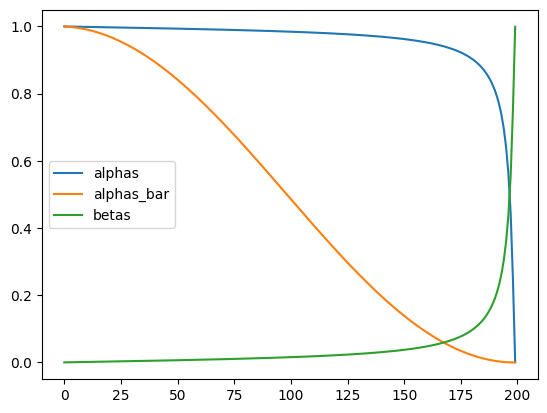

In [12]:
import matplotlib.pyplot as plt

plt.plot(timesteps[:-1].cpu().numpy(), alphas.cpu().numpy(), label="alphas")
plt.plot(timesteps[:-1].cpu().numpy(), alphas_bar.cpu().numpy(), label="alphas_bar")
plt.plot(timesteps[:-1].cpu().numpy(), betas.cpu().numpy(), label="betas")
plt.legend()

In [13]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

In [14]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

warmup_steps = 1_000
total_steps = 50_000

scheduler_lr = SequentialLR(
		opt,
		schedulers=[
			LinearLR(
				opt, start_factor=1e-6, end_factor=1.0, total_iters=warmup_steps
			),
			CosineAnnealingLR(opt, T_max=total_steps - warmup_steps),
		],
		milestones=[warmup_steps],
	)

In [15]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()

In [16]:
def q_sample(x0, t, scheduler, noise=None):
	if noise is None:
		noise = torch.randn_like(x0)

	alpha_bar = scheduler.alphas_bar[t].view(-1, 1, 1)
	x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise

	return x_t, noise

In [ ]:
import torch.nn.functional as F

def loss(x0_pred: torch.Tensor, x0: torch.Tensor, step: int):
    v_pred = x0_pred[:, 1:, :] - x0_pred[:, :-1, :]
    v_true = x0[:, 1:, :] - x0[:, :-1, :]

    l1 = F.mse_loss(x0_pred, x0)
    l2 = F.mse_loss(x0_pred[:, 1:, :], x0_pred[:, :-1, :])
    l3 = F.mse_loss(v_pred, v_true)

    writer.add_scalar("loss/l1", l1.item(), step)
    writer.add_scalar("loss/l2", l2.item(), step)
    writer.add_scalar("loss/l3", l3.item(), step)

    return l1 + 0.5 * l2 + 0.3 * l3

In [ ]:
from tqdm import tqdm

model = model.to(device)

step = 0
for epoch in range(1000):
    for x0 in tqdm(dataloader):
        x0 = x0["mhr"].to(device)
        x0 = x0[:, :, :136]

        B,L,D = x0.size()
        t = torch.randint(0, T, (B,), device=device).unsqueeze(1)

        x_t, noise = q_sample(x0, t, scheduler)

        x0_pred = model(x_t, t)

        l = loss(x0_pred, x0, step)

        opt.zero_grad()
        l.backward()
        opt.step()

        step += 1
        writer.add_scalar("loss", l.item(), step)


  0%|          | 0/728 [00:00<?, ?it/s]

 16%|█▌        | 118/728 [00:34<03:12,  3.17it/s]